In [ ]:
import pandas as pd
df=pd.read_excel("/content/Indian_Train_Delay_Cleaned.xlsx")
df.head()

,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27T12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27T12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27T12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27T12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...
4,12673,Cheran Express,JTJ,JOLARPETTAI,NaN,70.96,27.67,1.37,0.00,2025-09-27T12:25:44.585700+00:00,https://etrain.info/train/Cheran-Express-12673...


In [ ]:
df.shape

(1900, 11)

In [ ]:
df.columns

Index(['train_number', 'train_name', 'station_code', 'station_name',
       'average_delay_minutes', 'pct_right_time', 'pct_slight_delay',
       'pct_significant_delay', 'pct_cancelled_unknown', 'scraped_at',
       'source_url'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   train_number           1900 non-null   int64  
 1   train_name             1900 non-null   object 
 2   station_code           1900 non-null   object 
 3   station_name           1900 non-null   object 
 4   average_delay_minutes  1664 non-null   float64
 5   pct_right_time         1900 non-null   float64
 6   pct_slight_delay       1900 non-null   float64
 7   pct_significant_delay  1900 non-null   float64
 8   pct_cancelled_unknown  1900 non-null   float64
 9   scraped_at             1900 non-null   object 
 10  source_url             1900 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 163.4+ KB


In [ ]:
df.describe()

,train_number,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown
count,1900.000000,1664.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,13870.640000,40.699519,50.411721,32.965258,15.448874,1.174574
std,2904.322721,50.337954,33.082810,25.783788,22.303999,9.459637
min,11013.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12295.000000,13.000000,17.680000,11.110000,0.000000,0.000000
50%,12638.000000,24.000000,53.330000,28.000000,6.560000,0.000000
75%,15959.000000,49.000000,80.000000,50.237500,20.000000,0.000000
max,22652.000000,586.000000,100.000000,100.000000,100.000000,99.730000


In [ ]:
df.isnull().sum()

,0
train_number,0
train_name,0
station_code,0
station_name,0
average_delay_minutes,236
pct_right_time,0
pct_slight_delay,0
pct_significant_delay,0
pct_cancelled_unknown,0
scraped_at,0


In [ ]:
(df.isnull().sum()/len(df)*100).round(2)

,0
train_number,0.00
train_name,0.00
station_code,0.00
station_name,0.00
average_delay_minutes,12.42
pct_right_time,0.00
pct_slight_delay,0.00
pct_significant_delay,0.00
pct_cancelled_unknown,0.00
scraped_at,0.00


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Unique Train Numbers:", df['train_number'].nunique())
print("Unique Train Names:", df['train_name'].nunique())
print("Unique Stations:", df['station_code'].nunique())

Unique Train Numbers: 90
Unique Train Names: 42
Unique Stations: 480


In [ ]:
train_delay=(df.groupby(['train_number','train_name'])['average_delay_minutes'].mean()
.sort_values(ascending=False)
             )
train_delay.head(10)

,,average_delay_minutes
train_number,train_name,
12261,Howrah Duronto,370.500000
12262,Howrah Duronto,316.833333
12236,Duronto Express,148.000000
12509,Guwahati Sbc Express,143.189189
12839,Howrah Mail,109.365079
12626,Kerala Express,101.051282
12840,Howrah Mail,100.814286
12510,Sbc Guwahati Express,87.973684
12245,Duronto Express,78.200000


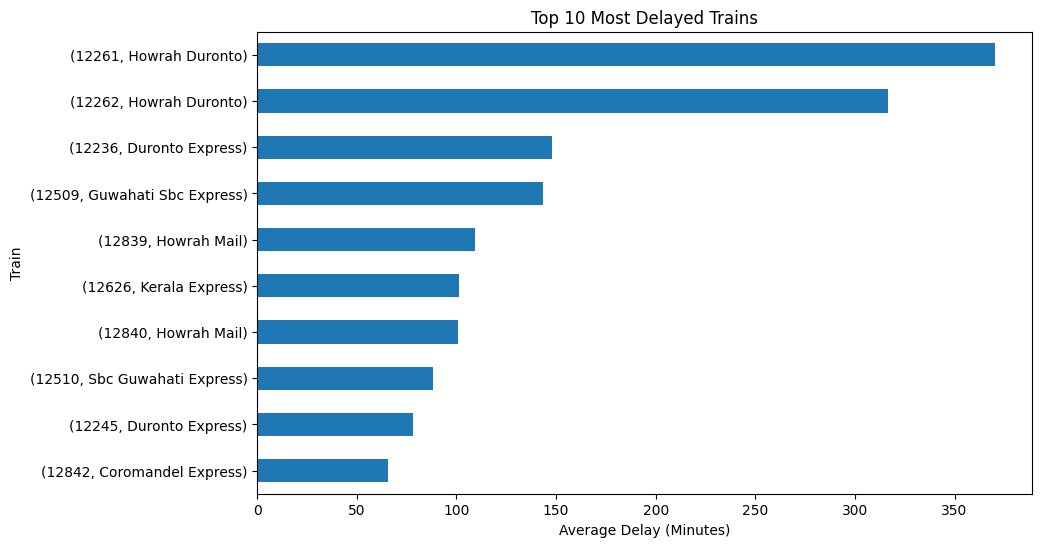

In [ ]:
import matplotlib.pyplot as plt
top10_trains=train_delay.head(10).sort_values()

plt.figure(figsize=(10,6))
top10_trains.plot(kind='barh')

plt.title('Top 10 Most Delayed Trains')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Train')
plt.show()

In [ ]:
station_delay=(
    df.groupby(['station_code','station_name'])['average_delay_minutes']
    .mean()
    .sort_values(ascending=False)
)
station_delay.head(10)

,,average_delay_minutes
station_code,station_name,
AK,AKOLA JN,429.500000
TATA,TATANAGAR JN,338.500000
BSP,BILASPUR JN,299.500000
DKAE,DANKUNI,149.000000
RPH,RAMPUR HAT,132.000000
SLO,SAMALKOT JN,126.500000
NDD,NIDADAVOLU JN,124.000000
RJY,RAJAMUNDRY,122.166667
ANV,ANNAVARAM,119.000000


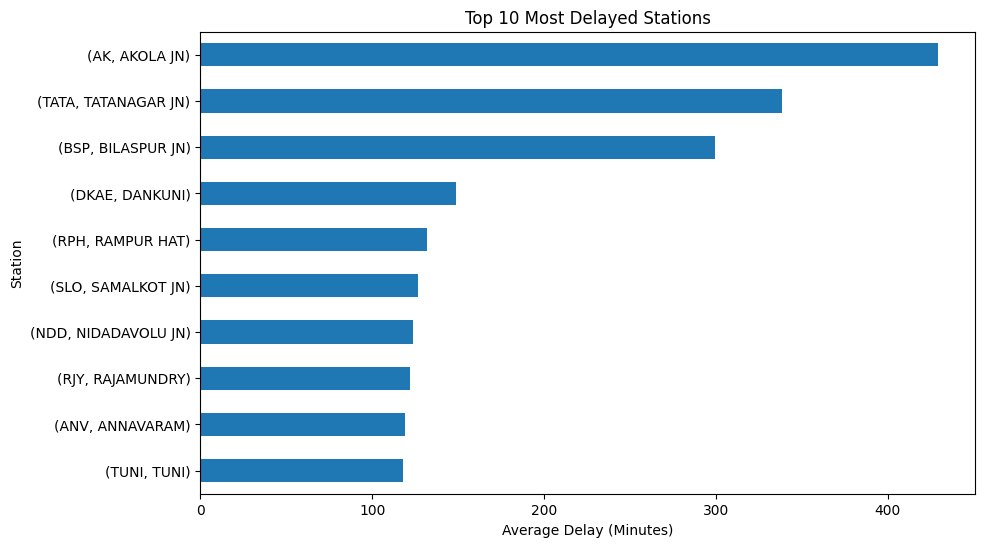

In [ ]:
import matplotlib.pyplot as plt
top10_stations=station_delay.head(10).sort_values()

plt.figure(figsize=(10,6))
top10_stations.plot(kind='barh')

plt.title('Top 10 Most Delayed Stations')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Station')
plt.show()

In [ ]:
best_trains = (
    df.groupby(['train_number', 'train_name'])['pct_right_time']
      .mean()
      .sort_values(ascending=False)
)

best_trains.head(10)

,,pct_right_time
train_number,train_name,
12306,Kolkata Rajdhani,100.000000
12049,Gatimaan Express,97.115000
12957,Swarna Jayanti Rajdhani,96.336000
12680,Coimbatore Intercity,93.333077
12313,Sealdah Rajdhani,89.583750
20665,Vande Bharat,88.942500
12434,Rajdhani,88.890000
12019,Shatabdi,88.888889
20666,Vande Bharat,87.500000


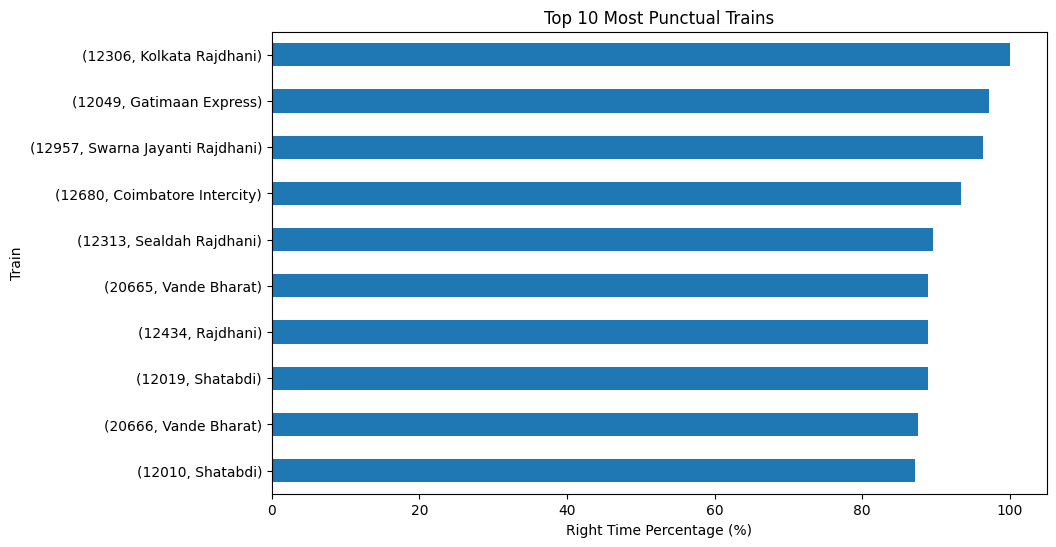

In [ ]:
top10_best = best_trains.head(10).sort_values()

plt.figure(figsize=(10, 6))
top10_best.plot(kind='barh')

plt.title('Top 10 Most Punctual Trains')
plt.xlabel('Right Time Percentage (%)')
plt.ylabel('Train')
plt.show()

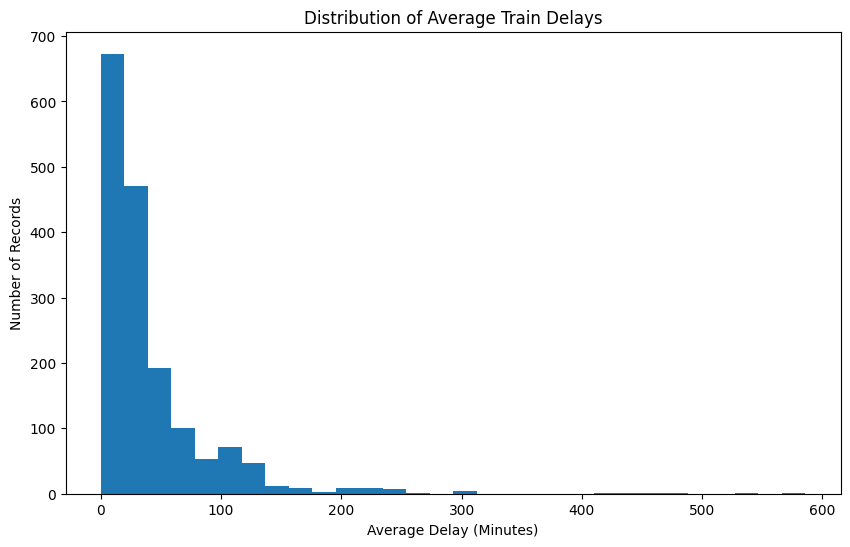

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['average_delay_minutes'].dropna(), bins=30)

plt.title('Distribution of Average Train Delays')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Number of Records')

plt.show()

In [ ]:
delay_status={
    'Right Time':df['pct_right_time'].mean(),
    'Slight Delay':df['pct_slight_delay'].mean(),
    'Significant Delay':df['pct_significant_delay'].mean(),
    'Cancelled / Unknown':df['pct_cancelled_unknown'].mean()
}
delay_status

{'Right Time': np.float64(50.411721052631584),
 'Slight Delay': np.float64(32.965257894736844),
 'Significant Delay': np.float64(15.448873684210527),
 'Cancelled / Unknown': np.float64(1.1745736842105263)}

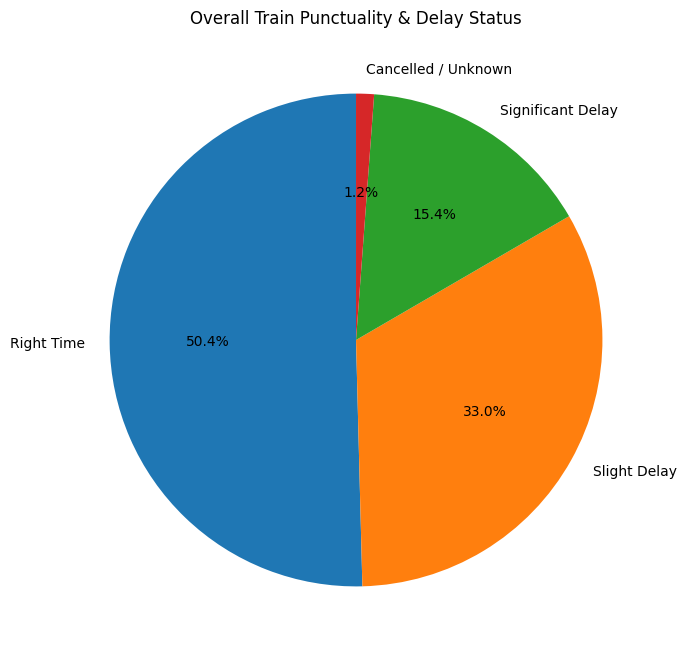

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    delay_status.values(),
    labels=delay_status.keys(),
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Overall Train Punctuality & Delay Status')
plt.show()

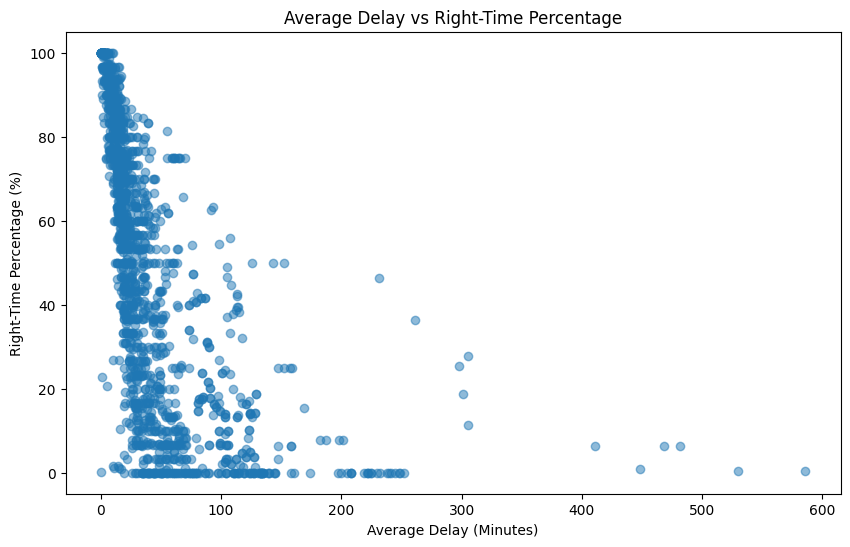

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['average_delay_minutes'],
    df['pct_right_time'],
    alpha=0.5
)

plt.title('Average Delay vs Right-Time Percentage')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Right-Time Percentage (%)')

plt.show()

In [ ]:
df[['average_delay_minutes', 'pct_right_time']].corr()

,average_delay_minutes,pct_right_time
average_delay_minutes,1.000000,-0.585116
pct_right_time,-0.585116,1.000000


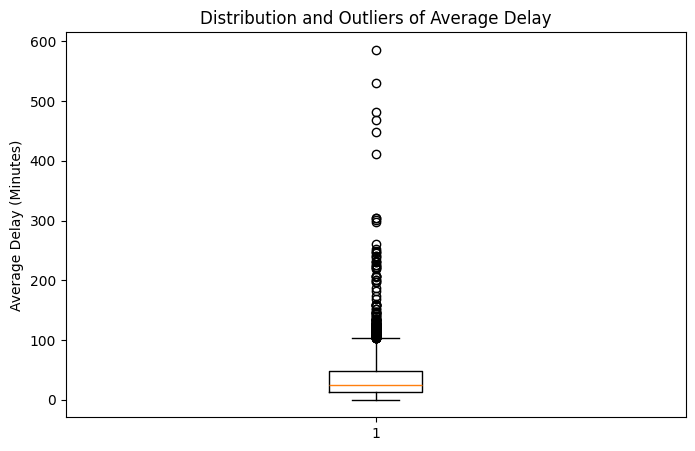

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df['average_delay_minutes'].dropna())

plt.title('Distribution and Outliers of Average Delay')
plt.ylabel('Average Delay (Minutes)')

plt.show()

In [ ]:
significant_delay = (
    df.groupby(['train_number', 'train_name'])['pct_significant_delay']
      .mean()
      .sort_values(ascending=False)
)

significant_delay.head(10)

,,pct_significant_delay
train_number,train_name,
12262,Howrah Duronto,75.781250
12509,Guwahati Sbc Express,69.105610
12839,Howrah Mail,67.047714
12261,Howrah Duronto,58.732500
12236,Duronto Express,54.166667
12510,Sbc Guwahati Express,48.847250
12245,Duronto Express,48.488333
12840,Howrah Mail,48.104444
12842,Coromandel Express,34.444444


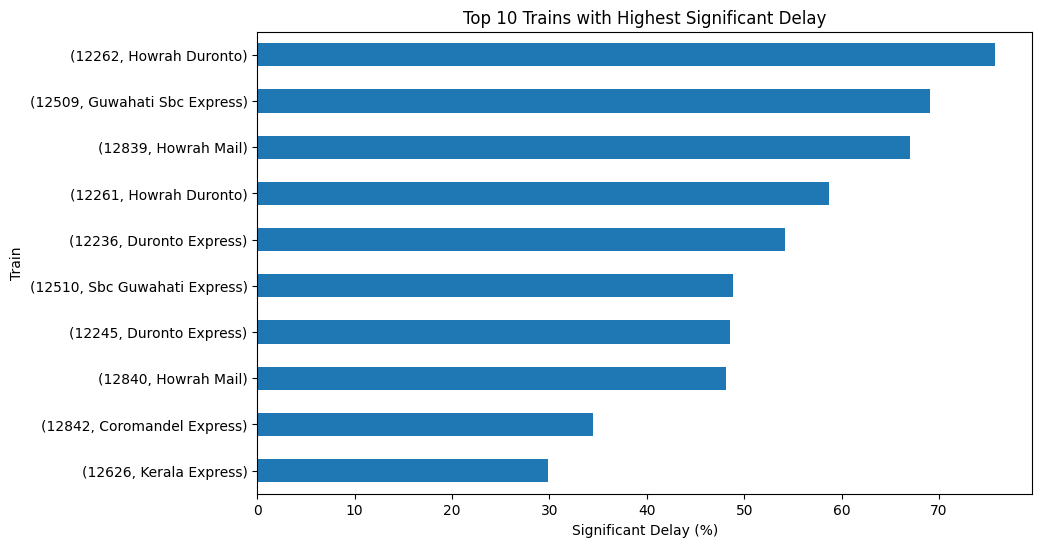

In [ ]:
top10_significant = significant_delay.head(10).sort_values()

plt.figure(figsize=(10, 6))

top10_significant.plot(kind='barh')

plt.title('Top 10 Trains with Highest Significant Delay')
plt.xlabel('Significant Delay (%)')
plt.ylabel('Train')

plt.show()

In [ ]:
train_performance = (
    df.groupby(['train_number', 'train_name'])[
        ['pct_right_time', 'pct_slight_delay', 'pct_significant_delay']
    ]
    .mean()
)

train_performance['performance_score'] = (
    train_performance['pct_right_time']
    - train_performance['pct_slight_delay']
    - train_performance['pct_significant_delay']
)

train_performance.sort_values(
    'performance_score',
    ascending=False
).head(10)

,,pct_right_time,pct_slight_delay,pct_significant_delay,performance_score
train_number,train_name,,,,
12306,Kolkata Rajdhani,100.000000,0.000000,0.000,100.000000
12049,Gatimaan Express,97.115000,2.885000,0.000,94.230000
12957,Swarna Jayanti Rajdhani,96.336000,0.333000,3.330,92.673000
12680,Coimbatore Intercity,93.333077,6.666923,0.000,86.666154
12313,Sealdah Rajdhani,89.583750,8.748750,1.665,79.170000
20665,Vande Bharat,88.942500,9.133750,1.925,77.883750
12434,Rajdhani,88.890000,11.110000,0.000,77.780000
12019,Shatabdi,88.888889,11.111111,0.000,77.777778
20666,Vande Bharat,87.500000,12.500000,0.000,75.000000


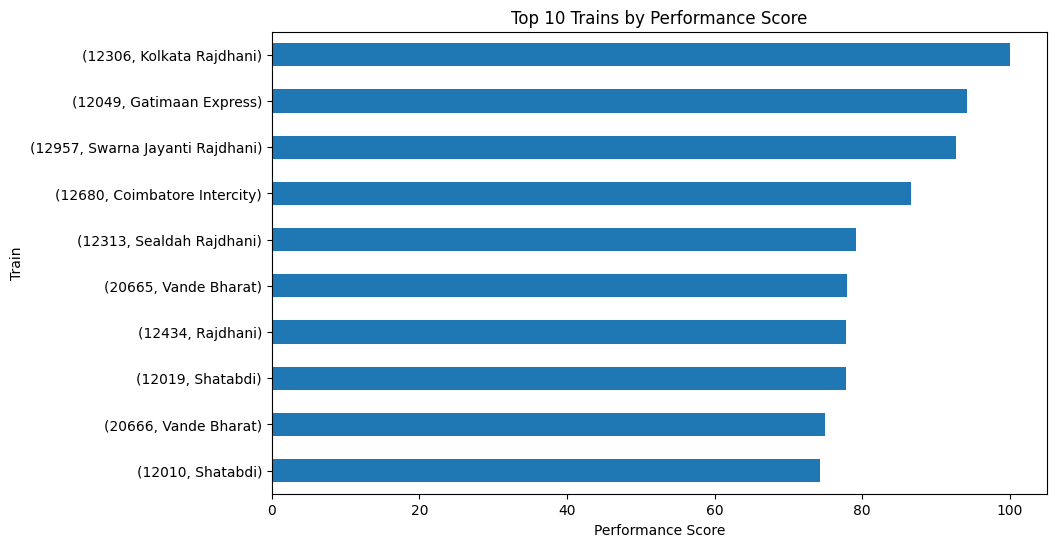

In [ ]:
top10_performance = (
    train_performance['performance_score']
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top10_performance.plot(kind='barh')

plt.title('Top 10 Trains by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Train')

plt.show()

In [ ]:
station_performance = (
    df.groupby(['station_code', 'station_name'])[
        ['pct_right_time', 'pct_slight_delay', 'pct_significant_delay']
    ]
    .mean()
)

station_performance['performance_score'] = (
    station_performance['pct_right_time']
    - station_performance['pct_slight_delay']
    - station_performance['pct_significant_delay']
)

station_performance.sort_values(
    'performance_score',
    ascending=False
).head(10)

,,pct_right_time,pct_slight_delay,pct_significant_delay,performance_score
station_code,station_name,,,,
NCJ,NAGERCOIL JN,100.000000,0.000,0.000,100.000000
PGTN,PALGHAT TOWN,100.000000,0.000,0.000,100.000000
SBIB,SABARMATI BG,98.335000,0.000,1.665,96.670000
DEC,DELHI CANTT,98.335000,0.000,1.665,96.670000
MS,CHENNAI EGMORE,97.600000,1.920,0.445,95.235000
ADI,AHMEDABAD JN,96.000000,4.000,0.000,92.000000
MURI,MURI,96.000000,4.000,0.000,92.000000
RNC,RANCHI,96.000000,4.000,0.000,92.000000
GGN,GURGAON,95.000000,3.335,1.665,90.000000


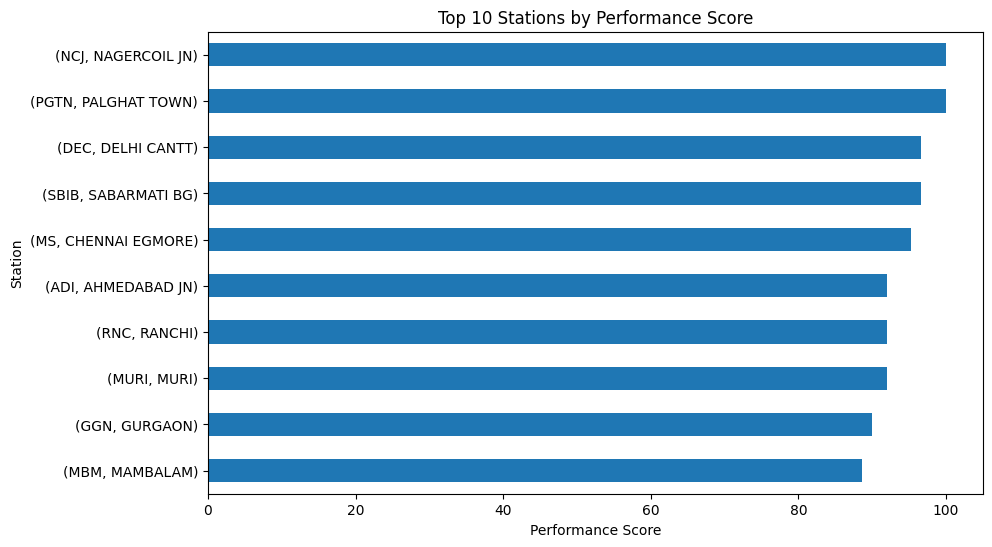

In [ ]:
top10_stations = (
    station_performance['performance_score']
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top10_stations.plot(kind='barh')

plt.title('Top 10 Stations by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Station')

plt.show()

In [ ]:
station_counts = (
    df.groupby(['station_code', 'station_name'])
      .size()
      .sort_values(ascending=False)
)

station_counts.head(10)

,,0
station_code,station_name,
NDLS,NEW DELHI,24
MAS,CHENNAI CENTRAL,22
HWH,HOWRAH JN,20
KYN,KALYAN JN,18
KPD,KATPADI JN,18
BZA,VIJAYAWADA JN,18
AJJ,ARAKKONAM,16
DDU,PT DEEN DAYAL UPADHYAY JN,16
TNA,THANE,14


In [ ]:
reliable_stations = station_counts[station_counts >= 10].index

In [ ]:
reliable_station_performance = station_performance.loc[
    station_performance.index.intersection(reliable_stations)
]

In [ ]:
reliable_station_performance.sort_values(
    'performance_score',
    ascending=True
).head(10)

,,pct_right_time,pct_slight_delay,pct_significant_delay,performance_score
station_code,station_name,,,,
BBS,BHUBANESWAR,4.327000,36.877000,58.704000,-91.254000
BZA,VIJAYAWADA JN,27.666111,43.890556,28.300556,-44.525000
KYN,KALYAN JN,37.743889,47.367222,14.846667,-24.470000
PER,PERAMBUR,39.268000,45.972000,14.651000,-21.355000
SUR,SOLAPUR JN,41.111000,52.030000,6.858000,-17.777000
NGP,NAGPUR,42.842000,32.937000,24.058000,-14.153000
PUNE,PUNE JN,45.100000,49.614000,5.285000,-9.799000
ED,ERODE JN,49.338000,44.329000,6.334000,-1.325000
TNA,THANE,52.417857,39.164286,8.419286,4.834286


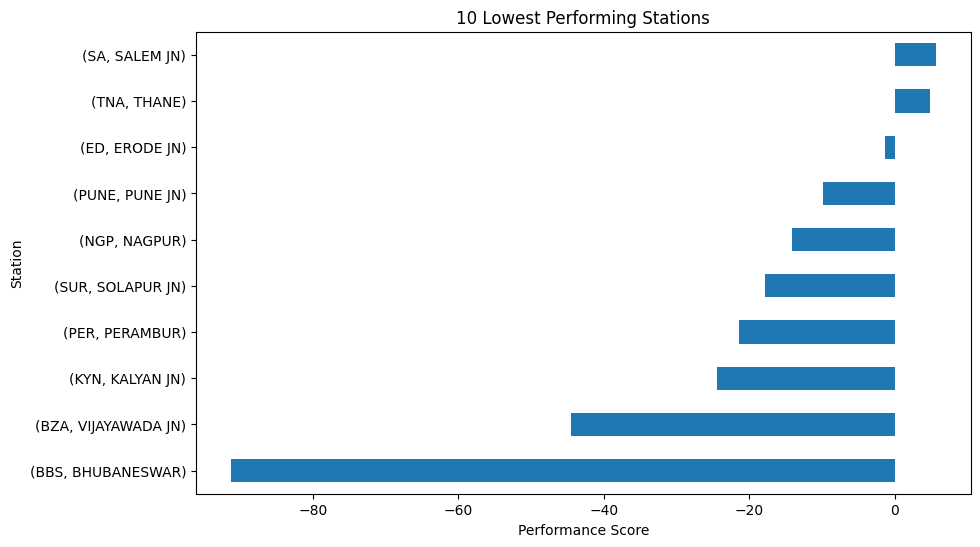

In [ ]:
worst10_stations = (
    reliable_station_performance['performance_score']
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))

worst10_stations.plot(kind='barh')

plt.title('10 Lowest Performing Stations')
plt.xlabel('Performance Score')
plt.ylabel('Station')

plt.show()

In [ ]:
kpis = {
    'Total Records': len(df),
    'Unique Trains': df['train_number'].nunique(),
    'Unique Stations': df['station_code'].nunique(),
    'Average Delay (min)': df['average_delay_minutes'].mean(),
    'Average Right-Time %': df['pct_right_time'].mean(),
    'Average Slight Delay %': df['pct_slight_delay'].mean(),
    'Average Significant Delay %': df['pct_significant_delay'].mean(),
    'Average Cancelled/Unknown %': df['pct_cancelled_unknown'].mean()
}

pd.Series(kpis).round(2)

,0
Total Records,1900.00
Unique Trains,90.00
Unique Stations,480.00
Average Delay (min),40.70
Average Right-Time %,50.41
Average Slight Delay %,32.97
Average Significant Delay %,15.45
Average Cancelled/Unknown %,1.17


In [ ]:
print("===== Railway Delay Analysis Summary =====")
print(f"Total Records: {len(df)}")
print(f"Unique Trains: {df['train_number'].nunique()}")
print(f"Unique Stations: {df['station_code'].nunique()}")
print(f"Average Delay: {df['average_delay_minutes'].mean():.2f} minutes")
print(f"Average Right-Time: {df['pct_right_time'].mean():.2f}%")

===== Railway Delay Analysis Summary =====
Total Records: 1900
Unique Trains: 90
Unique Stations: 480
Average Delay: 40.70 minutes
Average Right-Time: 50.41%
